# Solve LP

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import (LpProblem, LpMaximize, LpMinimize, LpVariable,
                  LpStatus, value, constants,)


# ── helpers ───────────────────────────────────────────────────────────────────

def _is_mip(model):
    """Return True if the model contains at least one integer/binary variable."""
    return any(v.cat in (constants.LpInteger, constants.LpBinary)
               for v in model.variables())


def _get_constraint_components(constraint, x1_var, x2_var):
    """Return (a1, a2, b, sense) for a PuLP constraint."""
    a1 = constraint.get(x1_var, 0)
    a2 = constraint.get(x2_var, 0)
    b = -constraint.constant          # PuLP stores LHS - b, so constant = -b
    sense = constraint.sense          # -1 (<=), 0 (=), 1 (>=)
    return a1, a2, b, sense


def _constraint_satisfied(a1, a2, b, sense, X1, X2):
    """Boolean mask: is the constraint satisfied on a meshgrid?"""
    lhs = a1 * X1 + a2 * X2
    if sense == -1:
        return lhs <= b + 1e-9
    if sense == 1:
        return lhs >= b - 1e-9
    return np.abs(lhs - b) <= 1e-7


# ── LP-only helpers ───────────────────────────────────────────────────────────

def _lp_binding_constraints(model):
    binding = []
    for name, c in model.constraints.items():
        if c.slack is not None and abs(c.slack) < 1e-7:
            binding.append(name)
    return binding


def _lp_multiple_optima(model):
    """
    Two signals:
      - A bounded variable at its bound with zero reduced cost (dj).
      - An active inequality with zero shadow price (pi) — covers the case
        where non-negativity is added as an explicit constraint.
    """
    def at_bound(v):
        val = value(v)
        if v.lowBound is not None and abs(val - v.lowBound) < 1e-7:
            return True
        if v.upBound is not None and abs(val - v.upBound) < 1e-7:
            return True
        return False

    has_multiple_vars = any(
        v.dj is not None and abs(v.dj) < 1e-7 and at_bound(v)
        for v in model.variables()
        if v.lowBound is not None or v.upBound is not None
    )
    has_multiple_cons = any(
        c.pi is not None and abs(c.pi) < 1e-7 and abs(c.slack) < 1e-7
        for c in model.constraints.values()
    )
    return has_multiple_vars or has_multiple_cons


# ── MIP-only helpers ──────────────────────────────────────────────────────────

def _mip_binding_constraints(model, x1_var, x2_var):
    """Recompute constraint activity from the primal solution (duals unavailable)."""
    binding = []
    for name, c in model.constraints.items():
        a1, a2, b, sense = _get_constraint_components(c, x1_var, x2_var)
        lhs_val = a1 * value(x1_var) + a2 * value(x2_var)
        slack = b - lhs_val if sense == -1 else lhs_val - b
        if abs(slack) < 1e-7:
            binding.append(name)
    return binding


def _mip_multiple_optima(model, x1_var, x2_var, XI, YI, int_feasible):
    """Check if more than one integer feasible point achieves the optimal Z."""
    opt_Z = value(model.objective)
    c1 = model.objective.get(x1_var, 0)
    c2 = model.objective.get(x2_var, 0)
    Z_grid = c1 * XI + c2 * YI
    return int(np.sum(int_feasible & (np.abs(Z_grid - opt_Z) < 1e-6))) > 1


# ── main function ─────────────────────────────────────────────────────────────

def analyze_lp(model, var_names=("x1", "x2"), plot_range=(0, 20), n_points=400,
               iso_progression=None, figsize=(10, 10)):
    """
    Solve a 2-variable LP or MIP, report status, binding constraints, and plot
    the feasible region, constraint lines, isoquants, and optimal solution.

    Works transparently for:
      - Pure LP  (LpVariable with cat='Continuous', the default)
      - MIP/IP   (any variable with cat='Integer' or cat='Binary')

    Parameters
    ----------
    model          : pulp.LpProblem  (objective + constraints already added)
    var_names      : (str, str)  names of the two decision variables
    plot_range     : (float, float)  axis limits, e.g. (0, 15)
    n_points       : int  grid resolution for shading / integer enumeration
    iso_progression: list[float] or None  extra Z-values for isoquant lines
    figsize        : (float, float)
    """
    mip = _is_mip(model)

    # ── 1. Solve ──────────────────────────────────────────────────────────────
    model.solve()
    status_label = LpStatus[model.status]

    # ── 2. Variable handles ───────────────────────────────────────────────────
    var_dict = {v.name: v for v in model.variables()}
    x1_var = var_dict[var_names[0]]
    x2_var = var_dict[var_names[1]]
    opt_x1 = value(x1_var)
    opt_x2 = value(x2_var)
    opt_Z  = value(model.objective)

    # ── 3. Feasibility grids ──────────────────────────────────────────────────
    lo, hi = plot_range
    x1_line = np.linspace(lo, hi, n_points)

    # Continuous grid (for shading)
    X1c, X2c = np.meshgrid(x1_line, np.linspace(lo, hi, n_points))
    cont_masks = [X1c >= 0, X2c >= 0]

    # Integer grid (MIP only)
    if mip:
        i_vals = np.arange(int(np.floor(lo)), int(np.ceil(hi)) + 1, dtype=float)
        XI, YI = np.meshgrid(i_vals, i_vals)
        int_feasible = (XI >= 0) & (YI >= 0)

    for constraint in model.constraints.values():
        a1, a2, b, sense = _get_constraint_components(constraint, x1_var, x2_var)
        cont_masks.append(_constraint_satisfied(a1, a2, b, sense, X1c, X2c))
        if mip:
            int_feasible &= _constraint_satisfied(a1, a2, b, sense, XI, YI)

    # Also apply explicit variable bounds to both grids
    for var, Xg, Xgi in [(x1_var, X1c, XI if mip else None),
                          (x2_var, X2c, YI if mip else None)]:
        if var.lowBound is not None:
            cont_masks.append(Xg >= var.lowBound)
            if mip:
                int_feasible &= Xgi >= var.lowBound
        if var.upBound is not None:
            cont_masks.append(Xg <= var.upBound)
            if mip:
                int_feasible &= Xgi <= var.upBound

    cont_feasible = np.logical_and.reduce(cont_masks)

    # ── 4. Status string ──────────────────────────────────────────────────────
    if status_label == "Optimal":
        if mip:
            has_multiple = _mip_multiple_optima(model, x1_var, x2_var,
                                                XI, YI, int_feasible)
        else:
            has_multiple = _lp_multiple_optima(model)
        output_status = "Optimal, multiple solutions" if has_multiple else "Optimal, unique solution"
    else:
        output_status = status_label

    # ── 5. Console output ─────────────────────────────────────────────────────
    problem_type = "MIP" if mip else "LP"
    print(f"[{problem_type}] Status: {output_status}")

    if status_label != "Optimal":
        print("No optimal solution to report.")
        return

    print(f"Z = {opt_Z},  {var_names[0]} = {opt_x1},  {var_names[1]} = {opt_x2}")

    print("\nBinding Constraints:")
    binding = (_mip_binding_constraints(model, x1_var, x2_var) if mip
               else _lp_binding_constraints(model))
    if binding:
        for name in binding:
            print(f"  - {name}")
    else:
        print("  (none)")

    # ── 6. Plot ───────────────────────────────────────────────────────────────
    c1 = model.objective.get(x1_var, 0)
    c2 = model.objective.get(x2_var, 0)

    fig, ax = plt.subplots(figsize=figsize)
    colors = ['blue', 'red', 'orange', 'brown', 'magenta', 'cyan', 'olive']
    color_idx = 0

    # Constraint boundary lines
    for name, constraint in model.constraints.items():
        a1, a2, b, sense = _get_constraint_components(constraint, x1_var, x2_var)

        # x_i >= 0 lines coincide with axes — skip drawing, still included in mask
        if (a1 == 0) != (a2 == 0) and b == 0:
            color_idx += 1
            continue

        sense_str = {-1: r'\leq', 0: '=', 1: r'\geq'}[sense]
        parts = []
        if a1:
            parts.append(f'{a1:g}{var_names[0]}')
        if a2:
            parts.append(f'{a2:g}{var_names[1]}')
        lhs_str = ' + '.join(parts) or '0'
        label = f'${lhs_str} {sense_str} {b:g}$ ({name})'

        color = colors[color_idx % len(colors)]
        if a2 != 0:
            ax.plot(x1_line, (b - a1 * x1_line) / a2,
                    label=label, color=color, lw=2)
        elif a1 != 0:
            ax.axvline(b / a1, label=label, color=color, lw=2)
        color_idx += 1

    # Shade LP relaxation feasible region
    ax.contourf(X1c, X2c, cont_feasible.astype(int),
                levels=[0.5, 1.5], colors=['green'], alpha=0.20)
    ax.fill_between([], [], [], color='green', alpha=0.20,
                    label='Feasible Region' + (' (LP relaxation)' if mip else ''))

    # MIP: scatter integer feasible points, highlight optimal ones
    if mip:
        Z_int = c1 * XI + c2 * YI
        non_opt = int_feasible & (np.abs(Z_int - opt_Z) >= 1e-6)
        opt_int = int_feasible & (np.abs(Z_int - opt_Z) < 1e-6)

        ax.scatter(XI[non_opt], YI[non_opt], color='green', s=25,
                   zorder=4, alpha=0.6, label='Feasible integer points')
        if np.any(opt_int):
            ax.scatter(XI[opt_int], YI[opt_int], color='gold',
                       edgecolors='black', s=80, zorder=5,
                       label=f'Optimal integer point(s)  Z={opt_Z:g}')

    # Isoquant lines
    if iso_progression is None:
        iso_progression = [round(opt_Z * 0.3, 2), round(opt_Z * 0.6, 2)]

    if c2 != 0:
        for z_val, style, alpha in ([(z, ':', 0.4) for z in iso_progression]
                                    + [(opt_Z, '-', 1.0)]):
            iso_y = (z_val - c1 * x1_line) / c2
            ax.plot(x1_line, iso_y, linestyle=style, color='purple', alpha=alpha,
                    label=f'Isoquant Z={z_val:g}' if z_val == opt_Z else None)

    # Optimal point marker  (* for MIP, o for LP)
    marker, msize = ('*', 14) if mip else ('o', 8)
    ax.plot(opt_x1, opt_x2, marker=marker, color='black', markersize=msize, zorder=6)
    offset = (hi - lo) * 0.06
    ax.annotate(f'Optimal\n({opt_x1:g}, {opt_x2:g})\nZ={opt_Z:g}',
                xy=(opt_x1, opt_x2),
                xytext=(opt_x1 + offset, opt_x2 + offset),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                fontsize=9)

    # Axes and labels
    ax.set_xlim(lo, hi * 0.9)
    ax.set_ylim(lo, hi * 0.9)
    ax.set_xlabel(f'${var_names[0]}$', fontsize=12)
    ax.set_ylabel(f'${var_names[1]}$', fontsize=12)
    ptype_title = "Integer Programming (MIP)" if mip else "Linear Programming (LP)"
    ax.set_title(f'{ptype_title}: Feasible Region, Constraints & Isoquants', fontsize=13)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

    if mip:
        ax.set_xticks(np.arange(int(lo), int(hi * 0.9) + 1))
        ax.set_yticks(np.arange(int(lo), int(hi * 0.9) + 1))

    plt.tight_layout()
    plt.show()

[LP] Status: Optimal, unique solution
Z = 126.0,  x1 = 0.0,  x2 = 7.0

Binding Constraints:
  - Hours
  - sign1


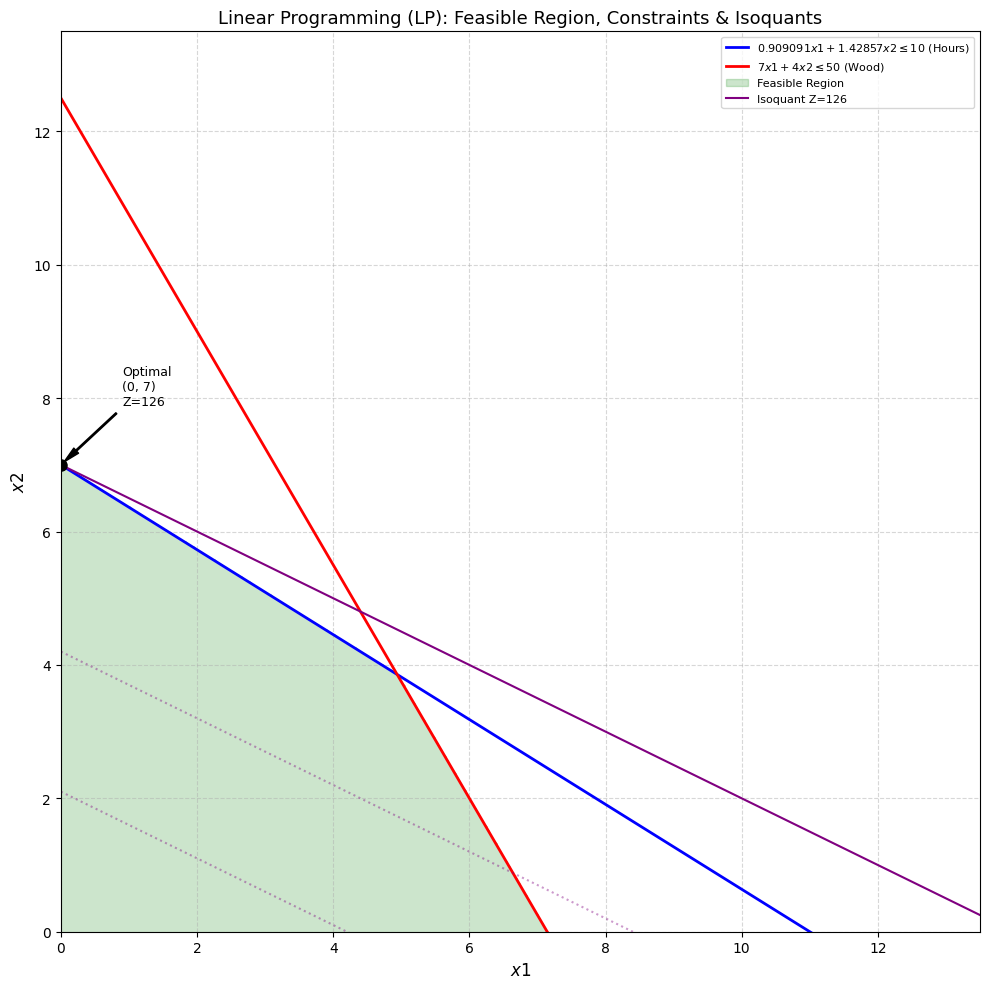

In [ ]:
model = LpProblem("Maximization_Problem", LpMaximize)
 
# No lowBound — variables are free; non-negativity added as constraints below
w = [5, 7, 4, 3]
v = [16, 22, 12, 8]

xwv = {f'x{i}': {
        'x': LpVariable(f"x{i}", cat='Binary'),
        'w': w[i],
        'v': v[i]
    }  for i in range(0,3)
}


 
model += sum(v['x']*v['v'] for v in xwv.values()), "Objective"
model += sum(v['x']*v['w'] for v in xwv.values()) <= 10, "Hours"

 
analyze_lp(model, var_names=tuple(vwx.keys()), plot_range=(0, 15))